# Lifetime GDP in Germany

Source: https://data.worldbank.org/indicator/NY.GDP.MKTP.KD.ZG?end=2024&locations=DE&start=1961&view=chart

In [29]:
import pandas as pd
from matplotlib import pyplot as plt

In [5]:
data = {
    "gdp-growth": pd.read_csv("./data/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107.csv", skiprows=4)
}

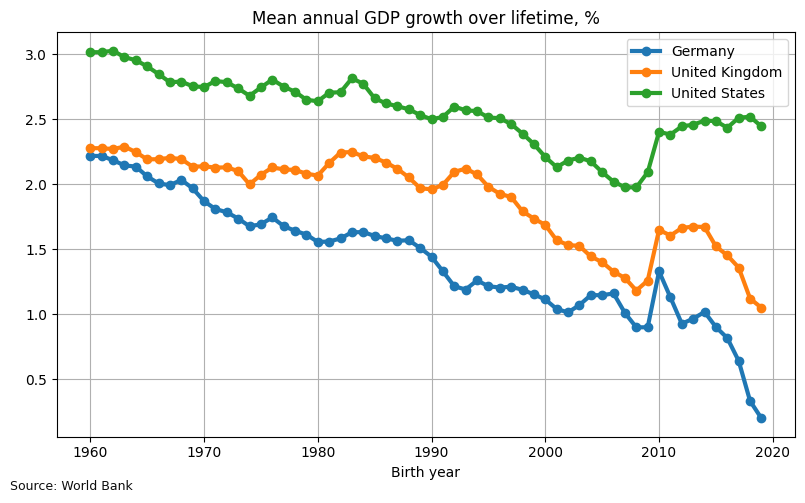

In [ ]:
countries = ["Germany", "United Kingdom", "United States"]

d = data["gdp-growth"].loc[data["gdp-growth"]["Country Name"].isin(countries)].melt(id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])[["Country Name", "Country Code", "variable", "value"]].rename(columns={"variable": "year", "Country Name": "country_name"})

d["year"] = d["year"].apply(pd.to_datetime)
d["value"] = d["value"].astype(float)

res = []

for y in range(1960, 2020):
	for c in countries:
		avg_growth = d.loc[(d["country_name"] == c) & (d["year"] >= f"{y}")]["value"].mean()
		res.append({"year": y, "avg_growth": avg_growth, "country": c})
	
result = pd.DataFrame(res).set_index(["year"]).pivot(columns="country", values="avg_growth")

fig,ax = plt.subplots(figsize=(8,5))
result.plot(ax=ax, linewidth=3)
ax.set_title("Mean annual GDP growth over lifetime, %")
ax.set_xlabel("Birth year")
ax.legend()
ax.grid(axis="both")
plt.tight_layout()
ax.text(x=0, y=.01, s="Source: World Bank", transform=fig.transFigure, ha='left', fontsize=9, alpha=.95, linespacing=1.35)
plt.show()